# Feeding-Strategy Experiment — Combined Analysis (honors)

Merges two runs into one picture **without conflating incomparable arms**:

- **`exp_feeding_strategies.csv`** (exp 2): five **budget-matched** arms at full $P$ —
  `C_splitdata_fullcols`, `B_in_sqrt`, `B_in_dm`, `D_sqrt_fullP`, `D_dm_fullP`. **This file alone
  defines the primary feeding ranking**, because all five arms share the same per-SVM feature budget.
- **`exp_width_depth_scenarios.csv`** (exp 1): contributes the **`baseline_fullinput`** ($m{=}1$
  reference and full/full $m{>}1$) and **`featpart_fulldata`** (the $\Phi$-partition arm exp 2 did not run).

**Quarantined (NOT pooled):** exp 1's `input_subspace_sqrt`/`input_subspace_dm` ran at the **old $P/m$
budget** and at $m{=}1$ degenerate settings, and the file lacks a `full_data` flag to disambiguate
B vs D. They appear **only** in the budget-ablation table, never in the ranking.

Every row is tagged with `source`, `arm`, and `role` so no incomparable arms are silently mixed.
This guards the headline conclusion — *which feeding strategy is best, given $m{>}1$* — against the
budget/axis confounds.

In [65]:
import os, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width",170); pd.set_option("display.max_columns",60)

P_FEED = "../results/1_exp_feeding_strategies.csv"
P_WD   = "../results/1_exp_width_depth_scenarios.csv"
if not os.path.exists(P_FEED):
    P_FEED="exp_feeding_strategies.csv"; P_WD="exp_width_depth_scenarios.csv"
OUT="tables"; os.makedirs(OUT,exist_ok=True)

## 1. Load both files (schema-robust) and tag provenance
The feeding CSV may be 16-col headerless or 23-col; the width_depth CSV is 16-col with a `split_id`
column. We normalise both, derive `arm`/`m`/`L` from the `model` string, and tag `source`.

In [66]:
S_FEED16=["exp_id","dataset","n_total","n_train","n_test","d","n_classes","model","kernel",
          "L","m","P","mean_cos_sim","acc","time_s","timestamp"]

def read_any(path):
    with open(path) as f: first=f.readline().strip().split(",")
    has_hdr = first[0]=="exp_id" and not first[-1][:4].isdigit()
    if has_hdr: return pd.read_csv(path)
    return pd.read_csv(path, names=S_FEED16)   # feeding fallback only

def prep(path, source):
    df=read_any(path); df.columns=[c.strip() for c in df.columns]
    df["source"]=source
    df["arm"]=df["model"].astype(str).str.replace(r"_m\d+_L\d+$","",regex=True)
    if "m" not in df or df["m"].isna().all(): df["m"]=df["model"].str.extract(r"_m(\d+)_L").astype(float)
    if "L" not in df or df["L"].isna().all(): df["L"]=df["model"].str.extract(r"_L(\d+)$").astype(float)
    for c in ["n_train","n_total","d","n_classes","m","L","P","acc","time_s","mean_cos_sim"]:
        if c in df: df[c]=pd.to_numeric(df[c],errors="coerce")
    if "mean_cos_sim" not in df: df["mean_cos_sim"]=np.nan
    df["cos"]=df["mean_cos_sim"]
    keep=["source","dataset","n_train","d","n_classes","arm","m","L","P","acc","cos","time_s"]
    return df[[c for c in keep if c in df.columns]]

feed=prep(P_FEED,"feeding"); wd=prep(P_WD,"width_depth")
df=pd.concat([feed,wd],ignore_index=True)
KEEP_DATASETS = ["MNIST","FashionMNIST","Gisette","HIGGS","CoverType","Optdigits"]
df = df[df.dataset.isin(KEEP_DATASETS)].copy()
print("feeding rows:",len(feed)," width_depth rows:",len(wd))
print("arms (feeding):",sorted(feed.arm.unique()))
print("arms (width_depth):",sorted(wd.arm.unique()))
df.head()

feeding rows: 2404  width_depth rows: 1332
arms (feeding): ['B_in_dm', 'B_in_sqrt', 'C_splitdata_fullcols', 'D_dm_fullP', 'D_sqrt_fullP']
arms (width_depth): ['baseline_fullinput', 'featpart_fulldata', 'input_subspace_dm', 'input_subspace_sqrt']


,source,dataset,n_train,d,n_classes,arm,m,L,P,acc,cos,time_s
0,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,1,1000,0.5737,NaN,0.26
1,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,1,1000,0.5768,NaN,0.25
2,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,1,1000,0.5709,NaN,0.27
3,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,2,1000,0.5739,NaN,0.28
4,feeding,HIGGS,1000,28,2,C_splitdata_fullcols,1,2,1000,0.5757,NaN,0.23


## 2. Assign role — the safety mechanism
`ranking` = the five budget-matched feeding arms from exp 2 (primary question). `enrich` = exp 1's
baseline + featpart. `ablation_old` = exp 1's old-$P/m$ subspace arms (quarantined). Anything else →
`other` and is excluded from all summary tables.

In [67]:
FEEDING_ARMS={"C_splitdata_fullcols","B_in_sqrt","B_in_dm","D_sqrt_fullP","D_dm_fullP"}
ENRICH_ARMS={"baseline_fullinput","featpart_fulldata"}
ABLATION_OLD={"input_subspace_sqrt","input_subspace_dm"}
def role(r):
    if r.source=="feeding" and r.arm in FEEDING_ARMS: return "ranking"
    if r.source=="width_depth" and r.arm in ENRICH_ARMS: return "enrich"
    if r.source=="width_depth" and r.arm in ABLATION_OLD: return "ablation_old"
    return "other"
df["role"]=df.apply(role,axis=1)
print(df.role.value_counts().to_string())
# nice labels
NICE={"C_splitdata_fullcols":"Instance Partitioning","B_in_sqrt":"Feature Subsampling","B_in_dm":"Feature Partitioning",
      "D_sqrt_fullP":"Joint Partitioning (√d)","D_dm_fullP":"Joint Partitioning (d/m)",
      "baseline_fullinput":"Single SVM (baseline)","featpart_fulldata":"Feature Partitioning (Φ)"}
df["label"]=df.arm.map(lambda a: NICE.get(a,a))

role
ranking         2014
ablation_old     783
enrich           549


## 3. Aggregate to mean ± std over seeds (best L per cell)

In [68]:
def agg(sub):
    g=(sub.groupby(["dataset","label","arm","m","L","n_train"])
         .agg(acc_mean=("acc","mean"),acc_std=("acc","std"),cos=("cos","mean"),
              t=("time_s","mean"),seeds=("acc","size")).reset_index())
    g["acc_std"]=g.acc_std.fillna(0.0)
    bestL=g.sort_values("acc_mean",ascending=False).groupby(
        ["dataset","label","arm","m","n_train"]).first().reset_index()
    return g, bestL
cell, bestL = agg(df[df.role.isin(["ranking","enrich"])])
print(len(cell),"cells /",len(bestL),"best-L rows")
bestL.head()

739 cells / 309 best-L rows


,dataset,label,arm,m,n_train,L,acc_mean,acc_std,cos,t,seeds
0,CoverType,Feature Partitioning,B_in_dm,1,1000,1,0.666367,0.007703,NaN,1.286667,3
1,CoverType,Feature Partitioning,B_in_dm,1,5000,1,0.740867,0.002101,NaN,8.736667,3
2,CoverType,Feature Partitioning,B_in_dm,1,10000,2,0.767733,0.003004,NaN,23.803333,3
3,CoverType,Feature Partitioning,B_in_dm,10,1000,1,0.671967,0.005590,NaN,5.753333,3
4,CoverType,Feature Partitioning,B_in_dm,10,5000,2,0.728600,0.002615,NaN,116.350000,3


## 4. PRIMARY — feeding ranking at $m=10$ (ranking arms only)
Uses **only** the budget-matched exp 2 arms. A win counts only if the margin exceeds the seed spread.

In [69]:
rk=bestL[(bestL.arm.isin(FEEDING_ARMS))&(bestL.m==10)].copy()
rk["rank"]=rk.groupby(["dataset","n_train"]).acc_mean.rank(ascending=False)
ranking=rk.groupby("label")["rank"].agg(mean_rank="mean",cells="size").sort_values("mean_rank").round(2)
print("Overall feeding ranking @ m=10 (budget-matched arms only):"); display(ranking)

print("\nBest feeder per dataset×n (m=10):")
for (ds,n),g in rk.groupby(["dataset","n_train"]):
    g=g.sort_values("acc_mean",ascending=False)
    b=g.iloc[0]; margin=b.acc_mean-(g.iloc[1].acc_mean if len(g)>1 else np.nan)
    sig="" if (len(g)<2 or margin>b.acc_std) else "  (within seed band)"
    print(f"  {ds:10s} n={int(n):>6} -> {b.label:18s} {b.acc_mean:.4f}±{b.acc_std:.4f}{sig}")

Overall feeding ranking @ m=10 (budget-matched arms only):


,mean_rank,cells
label,,
Feature Partitioning,1.45,22
Instance Partitioning,1.78,18
Feature Subsampling,3.09,23
Joint Partitioning (d/m),3.12,16
Joint Partitioning (√d),4.94,16



Best feeder per dataset×n (m=10):
  CoverType  n=  1000 -> Feature Partitioning 0.6720±0.0056
  CoverType  n=  5000 -> Instance Partitioning 0.7365±0.0038
  CoverType  n= 10000 -> Instance Partitioning 0.7610±0.0044  (within seed band)
  CoverType  n= 50000 -> Instance Partitioning 0.7946±0.0030
  FashionMNIST n=  2000 -> Feature Partitioning 0.8340±0.0041
  FashionMNIST n= 10000 -> Feature Partitioning 0.8696±0.0023
  FashionMNIST n= 50000 -> Feature Partitioning 0.8915±0.0010
  Gisette    n=  2000 -> Feature Partitioning 0.9669±0.0047
  Gisette    n=  5600 -> Feature Partitioning 0.9709±0.0008
  HIGGS      n=  1000 -> Feature Partitioning 0.5947±0.0029
  HIGGS      n=  5000 -> Instance Partitioning 0.6387±0.0020
  HIGGS      n= 10000 -> Instance Partitioning 0.6445±0.0059
  HIGGS      n= 50000 -> Instance Partitioning 0.6703±0.0022
  HIGGS      n=100000 -> Instance Partitioning 0.6726±0.0064
  HIGGS      n=200000 -> Instance Partitioning 0.6767±0.0052
  MNIST      n=  1000 -> Featur

## 5. Per-dataset feeding tables @ m=10 (mean ± std)
Ranking arms + baseline (m=1) and B-Φ shown for context, but the ranking in §4 is the ranking arms only.

In [70]:
def show(ds,m=10):
    s=bestL[(bestL.dataset==ds)&(bestL.m==m)]
    pm=s.pivot_table(index="label",columns="n_train",values="acc_mean")
    ps=s.pivot_table(index="label",columns="n_train",values="acc_std")
    out=pm.astype(object).copy()
    for a in pm.index:
        for n in pm.columns:
            if pd.notna(pm.loc[a,n]): out.loc[a,n]=f"{pm.loc[a,n]:.4f} ± {ps.loc[a,n]:.4f}"
    return out
for ds in sorted(bestL.dataset.unique()):
    print(f"\n=== {ds}  (m=10) ==="); display(show(ds))


=== CoverType  (m=10) ===


n_train,1000,5000,10000,50000,100000
label,,,,,
Feature Partitioning,0.6720 ± 0.0056,0.7286 ± 0.0026,0.7570 ± 0.0042,NaN,NaN
Feature Partitioning (Φ),0.6811 ± 0.0086,0.7390 ± 0.0009,0.7557 ± 0.0045,0.7610 ± 0.0021,0.7584 ± 0.0050
Feature Subsampling,0.6347 ± 0.0363,0.6975 ± 0.0236,0.7256 ± 0.0206,0.7513 ± 0.0158,NaN
Instance Partitioning,NaN,0.7365 ± 0.0038,0.7610 ± 0.0044,0.7946 ± 0.0030,NaN
Joint Partitioning (d/m),NaN,0.7178 ± 0.0033,0.7302 ± 0.0038,NaN,NaN
Joint Partitioning (√d),NaN,0.6822 ± 0.0331,0.7010 ± 0.0320,NaN,NaN



=== FashionMNIST  (m=10) ===


n_train,2000,10000,50000
label,,,
Feature Partitioning,0.8340 ± 0.0041,0.8696 ± 0.0023,0.8915 ± 0.0010
Feature Subsampling,0.8075 ± 0.0043,0.8506 ± 0.0023,0.8716 ± 0.0007
Instance Partitioning,0.8112 ± 0.0010,0.8554 ± 0.0022,0.8758 ± 0.0023
Joint Partitioning (d/m),0.7909 ± 0.0037,0.8535 ± 0.0034,0.8763 ± 0.0002
Joint Partitioning (√d),0.7748 ± 0.0034,0.8394 ± 0.0026,0.8581 ± 0.0029



=== Gisette  (m=10) ===


...

n_train,1000,5000,10000,50000,100000,200000
label,,,,,,
Feature Partitioning,0.5947 ± 0.0029,0.6253 ± 0.0046,0.6376 ± 0.0058,0.6544 ± 0.0027,0.6551 ± 0.0033,0.6535 ± 0.0033
Feature Partitioning (Φ),0.6179 ± 0.0052,0.6418 ± 0.0046,0.6481 ± 0.0034,0.6533 ± 0.0045,0.6545 ± 0.0042,0.6517 ± 0.0039
Feature Subsampling,0.5805 ± 0.0128,0.6110 ± 0.0133,0.6254 ± 0.0205,0.6483 ± 0.0127,0.6543 ± 0.0089,0.6570 ± 0.0109
Instance Partitioning,NaN,0.6387 ± 0.0020,0.6445 ± 0.0059,0.6703 ± 0.0022,0.6726 ± 0.0064,0.6767 ± 0.0052
Joint Partitioning (d/m),NaN,0.6052 ± 0.0205,0.6244 ± 0.0087,0.6427 ± 0.0035,0.6455 ± 0.0029,0.6484 ± 0.0042
Joint Partitioning (√d),NaN,0.5841 ± 0.0106,0.6049 ± 0.0141,0.6268 ± 0.0080,0.6387 ± 0.0104,0.6461 ± 0.0105



=== MNIST  (m=10) ===


n_train,1000,5000,10000,50000
label,,,,
Feature Partitioning,0.8928 ± 0.0046,0.9430 ± 0.0033,0.9541 ± 0.0008,0.9709 ± 0.0010
Feature Partitioning (Φ),0.8535 ± 0.0043,0.9030 ± 0.0008,0.9185 ± 0.0009,0.9297 ± 0.0028
Feature Subsampling,0.8276 ± 0.0220,0.8979 ± 0.0050,0.9165 ± 0.0051,0.9388 ± 0.0039
Instance Partitioning,NaN,0.9134 ± 0.0019,0.9282 ± 0.0038,0.9490 ± 0.0006
Joint Partitioning (d/m),NaN,0.9086 ± 0.0013,0.9316 ± 0.0023,NaN
Joint Partitioning (√d),NaN,0.8800 ± 0.0062,0.8999 ± 0.0046,NaN



=== Optdigits  (m=10) ===


n_train,500,1000,2000,3823
label,,,,
Feature Partitioning,0.9345 ± 0.0091,0.9496 ± 0.0072,0.9647 ± 0.0032,0.9739 ± 0.0037
Feature Subsampling,0.9075 ± 0.0126,0.9267 ± 0.0098,0.9439 ± 0.0161,0.9549 ± 0.0054
Instance Partitioning,NaN,NaN,0.9757 ± 0.0054,0.9816 ± 0.0029
Joint Partitioning (d/m),NaN,NaN,0.9615 ± 0.0018,0.9659 ± 0.0014
Joint Partitioning (√d),NaN,NaN,0.9380 ± 0.0049,0.9605 ± 0.0052


## 6. SECONDARY — $m>1$ vs the $m=1$ baseline
Baseline = exp 1 `baseline_fullinput` at $m{=}1$ (the proper full/full reference). Gain flagged
significant when it exceeds the best arm's seed std.

In [71]:
rows=[]
for (ds,n),g in bestL.groupby(["dataset","n_train"]):
    base=g[(g.arm=="baseline_fullinput")&(g.m==1)]
    if base.empty: base=g[g.m==1]              # fallback
    bg=g[(g.arm.isin(FEEDING_ARMS))&(g.m>1)]
    if base.empty or bg.empty: continue
    b=base.acc_mean.max(); top=bg.loc[bg.acc_mean.idxmax()]
    rows.append(dict(dataset=ds,n=int(n),m1=round(b,4),best=round(top.acc_mean,4),
        std=round(top.acc_std,4),m=int(top.m),arm=top.label,gain=round(top.acc_mean-b,4),
        sig=bool(top.acc_mean-b>top.acc_std)))
gain=pd.DataFrame(rows); display(gain)
print("significant gains:",int(gain.sig.sum()),"/",len(gain))

,dataset,n,m1,best,std,m,arm,gain,sig
0,CoverType,1000,0.6653,0.6919,0.0058,50,Feature Partitioning,0.0265,True
1,CoverType,5000,0.7407,0.7618,0.0066,50,Feature Subsampling,0.0212,True
2,CoverType,10000,0.7683,0.8007,0.0045,50,Feature Subsampling,0.0324,True
3,CoverType,50000,0.7955,0.7946,0.0030,10,Instance Partitioning,-0.0009,False
4,FashionMNIST,2000,0.8025,0.8340,0.0041,10,Feature Partitioning,0.0314,True
5,FashionMNIST,10000,0.8342,0.8696,0.0023,10,Feature Partitioning,0.0354,True
6,FashionMNIST,50000,0.8739,0.8915,0.0010,10,Feature Partitioning,0.0176,True
7,Gisette,2000,0.9005,0.9669,0.0047,10,Feature Partitioning,0.0664,True
8,Gisette,5600,0.9057,0.9709,0.0008,10,Feature Partitioning,0.0652,True
9,HIGGS,1000,0.5738,0.6204,0.0071,50,Feature Subsampling,0.0465,True


significant gains: 17 / 23


## 7. SECONDARY — depth (L1→L2) and decorrelation

In [72]:
# depth
d2=cell[(cell.arm.isin(FEEDING_ARMS))&(cell.m>1)].pivot_table(index=['dataset','label','m','n_train'],columns='L',values='acc_mean')
if set([1,2]).issubset(d2.columns):
    d2=d2.dropna(subset=[1,2]); d2['dL']=d2[2]-d2[1]
    display(d2.groupby('dataset')['dL'].agg(['mean','median','count']).round(4))
# decorrelation — use FEEDING rows (width_depth has no cos)
fdf=df[(df.source=='feeding')&(df.m>1)&df.cos.notna()]
fc=fdf.groupby(['dataset','arm','m','L','n_train']).agg(acc=('acc','mean'),cos=('cos','mean')).reset_index()
print('corr(cos_sim, acc) by dataset:')
for ds,g in fc.groupby('dataset'):
    if len(g)>3: print(f'  {ds:10s} r={g.cos.corr(g.acc):+.3f} (n={len(g)})')


,mean,median,count
dataset,,,
CoverType,0.0125,0.0104,24
FashionMNIST,-0.0030,-0.0026,15
Gisette,-0.0026,-0.0011,10
HIGGS,0.0007,0.0009,39
MNIST,0.0012,0.0019,26
Optdigits,0.0066,0.0028,22


corr(cos_sim, acc) by dataset:


## 8. ABLATION (quarantined) — feature budget: old $P/m$ vs new full $P$
This is the *only* place exp 1's `input_subspace_*` arms appear, compared against exp 2's full-$P$
`D_*` arms **at $m>1$**. It measures how much the per-SVM feature budget matters — the empirical
justification for budget-matching. **Not part of the feeding ranking.**

In [73]:
abm={"input_subspace_sqrt":("D (√d)","old P/m"),"input_subspace_dm":("D (d/m)","old P/m"),
     "D_sqrt_fullP":("D (√d)","full P"),"D_dm_fullP":("D (d/m)","full P")}
ab=df[df.arm.isin(abm)].copy()
ab=ab[ab.m>1]
ab["subspace"]=ab.arm.map(lambda a:abm[a][0]); ab["budget"]=ab.arm.map(lambda a:abm[a][1])
abp=ab.groupby(["dataset","subspace","m","budget"]).acc.agg(
    lambda s:f"{s.mean():.4f} ± {s.std():.4f}" if len(s)>1 else f"{s.mean():.4f} ± 0.0000")
display(abp.unstack("budget"))
print("Reportable: at fixed (dataset, subspace, m), full P vs P/m isolates the budget effect.")

budget                             full P          old P/m
dataset      subspace m                                   
CoverType    D (d/m)  10  0.7204 ± 0.0080  0.7253 ± 0.0272
                      50  0.7316 ± 0.0133  0.7275 ± 0.0317
             D (√d)   10  0.6892 ± 0.0286  0.6978 ± 0.0370
                      50  0.7526 ± 0.0055  0.7428 ± 0.0328
FashionMNIST D (d/m)  10  0.8383 ± 0.0370              NaN
             D (√d)   10  0.8182 ± 0.0373              NaN
Gisette      D (d/m)  10  0.9437 ± 0.0076              NaN
             D (√d)   10  0.9070 ± 0.0123              NaN
HIGGS        D (d/m)  10  0.6296 ± 0.0185  0.6382 ± 0.0194
             D (√d)   10  0.6146 ± 0.0254  0.6253 ± 0.0239
                      50  0.6544 ± 0.0177  0.6582 ± 0.0209
MNIST        D (d/m)  10  0.9186 ± 0.0127  0.9029 ± 0.0328
                      50  0.9062 ± 0.0058  0.8867 ± 0.0472
             D (√d)   10  0.8779 ± 0.0192  0.8707 ± 0.0457
                      50  0.9186 ± 0.0050  0.8801 ± 0.0464
Optdigits    D (d/m)  10  0.9597 ± 0.0088              NaN
             D (√d)   10  0.9432 ± 0.0127              NaN

Reportable: at fixed (dataset, subspace, m), full P vs P/m isolates the budget effect.


## 9. Write LaTeX tables → `tables/`
Focused (ranking, per-dataset mean±std, m>1 gain, depth, decorrelation) + appendix (full grid) +
the budget-ablation table. All `booktabs`.

In [74]:
def esc(s): return str(s).replace("_",r"\_")
def tbl(body,cap,lab,spec,hdr):
    return ("\\begin{table}[ht]\n\\centering\\small\n\\begin{tabular}{%s}\n\\toprule\n%s \\\\\n\\midrule\n%s\\bottomrule\n\\end{tabular}\n\\caption{%s}\n\\label{%s}\n\\end{table}\n"%(spec,hdr,body,cap,lab))
DSORD=["HIGGS","CoverType","Optdigits","MNIST","FashionMNIST","Gisette"]

# ranking
body="".join(f"{esc(a)} & {r.mean_rank:.2f} & {int(r.cells)} \\\\\n" for a,r in ranking.iterrows())
open(f"{OUT}/feeding_ranking_m10.tex","w").write(tbl(body,
  "Diversity-strategy ranking at $m=10$ (budget-matched arms; lower mean rank better).",
  "tab:feeding_ranking","lcc","Feeding strategy & Mean rank & Cells"))

# per dataset mean±std (ranking arms only, bold best per column)
blocks=[]
for ds in [d for d in DSORD if d in bestL.dataset.unique()]:
    s=bestL[(bestL.dataset==ds)&(bestL.m==10)&(bestL.arm.isin(FEEDING_ARMS))]
    if s.empty: continue
    ns=sorted(s.n_train.unique())
    pm=s.pivot_table(index="label",columns="n_train",values="acc_mean")
    ps=s.pivot_table(index="label",columns="n_train",values="acc_std")
    best={n:pm[n].idxmax() for n in ns if pm[n].notna().any()}
    hdr="Arm & "+" & ".join(f"$n{{=}}{int(n)}$" for n in ns)
    bd=""
    for a in pm.index:
        cs=[]
        for n in ns:
            if pd.notna(pm.loc[a,n]):
                c=f"{pm.loc[a,n]:.4f}\\,$\\pm$\\,{ps.loc[a,n]:.4f}"
                if a==best.get(n): c=f"\\textbf{{{c}}}"
            else: c=""
            cs.append(c)
        bd+=f"{esc(a)} & "+" & ".join(cs)+" \\\\\n"
    blocks.append(tbl(bd,
      f"Feeding strategies on {esc(ds)} at $m=10$ (mean\\,$\\pm$\\,std; best per column bold).",
      f"tab:feed_{ds.lower()}","l"+"c"*len(ns),hdr))
open(f"{OUT}/feeding_per_dataset_m10.tex","w").write("\n".join(blocks))

# m gain
bd=""
for _,r in gain.sort_values(["dataset","n"]).iterrows():
    star="$^\\dagger$" if r.sig else ""
    bd+=(f"{esc(r.dataset)} & {int(r.n)} & {r.m1:.4f} & {r.best:.4f}\\,$\\pm$\\,{r['std']:.4f} & "
         f"{int(r.m)} & {esc(r.arm)} & {r.gain:+.4f}{star} \\\\\n")
open(f"{OUT}/m_gain.tex","w").write(tbl(bd,
  "Best $m>1$ feeding arm vs.\\ the $m=1$ baseline (mean\\,$\\pm$\\,std). "
  "$^\\dagger$: gain exceeds seed std.","tab:mgain","llcclll",
  "Dataset & $n$ & $m{=}1$ & best $m{>}1$ & $m$ & arm & gain"))

# budget ablation
au=abp.unstack("budget")
cols=list(au.columns)
hdr="Dataset & Subspace & $m$ & "+" & ".join(esc(c) for c in cols)
bd=""
for idx,row in au.iterrows():
    ds,ss,m=idx
    vals=" & ".join(("" if pd.isna(row[c]) else str(row[c])) for c in cols)
    bd+=f"{esc(ds)} & {esc(ss)} & {int(m)} & {vals} \\\\\n"
open(f"{OUT}/budget_ablation.tex","w").write(tbl(bd,
  "Feature-budget ablation ($m>1$): old $P/m$ vs full $P$ per SVM for the data-split $D$ arms. "
  "Quarantined from the feeding ranking.","tab:budget","lll"+"c"*len(cols),hdr))

# appendix (ranking+enrich full grid)
for ds in [d for d in DSORD if d in cell.dataset.unique()]:
    s=cell[cell.dataset==ds].sort_values(["n_train","label","m","L"])
    bd=""
    for _,r in s.iterrows():
        bd+=(f"{int(r.n_train)} & {esc(r.label)} & {int(r.m)} & {int(r.L)} & "
             f"{r.acc_mean:.4f}\\,$\\pm$\\,{r.acc_std:.4f} & "
             f"{('' if pd.isna(r.cos) else f'{r.cos:.3f}')} & {r.t:.1f} \\\\\n")
    open(f"{OUT}/appendix_{ds.lower()}.tex","w").write(tbl(bd,
      f"Complete results on {esc(ds)} (mean\\,$\\pm$\\,std over seeds; ranking + enrichment arms).",
      f"tab:app_{ds.lower()}","rlrrccr","$n$ & Arm & $m$ & $L$ & test acc & cos & t(s)"))
print("written:",sorted(os.listdir(OUT)))

written: ['appendix_covertype.tex', 'appendix_digits8x8.tex', 'appendix_fashionmnist.tex', 'appendix_gisette.tex', 'appendix_higgs.tex', 'appendix_mnist.tex', 'appendix_optdigits.tex', 'appendix_satimage.tex', 'budget_ablation.tex', 'feeding_decorrelation.tex', 'feeding_friedman.tex', 'feeding_per_dataset_m10.tex', 'feeding_ranking_m10.tex', 'm_gain.tex']


## 10. Proposed additional insights (from data you already have)

1. **Width sweep $m\in\{1,10,50\}$ as a curve** (exp 1 has $m{>}1$ full/full; exp 2 has all arms):
   plot accuracy vs $m$ per dataset to show where width saturates — feeds directly into the
   later width/depth experiment.
2. **B-Φ (feature partition) vs B-input (column subset):** exp 1's `featpart_fulldata` vs exp 2's
   `B_in_*` isolates *variable-blindness* (input subset) from *random-direction* partition (Φ subset)
   at matched $m$ — a clean mechanistic comparison.
3. **Depth $\times$ width interaction:** does $L{=}2$ help more at small or large $m$? Pivot
   $\Delta_L$ by $m$.
4. **Time–accuracy Pareto front:** plot mean accuracy vs mean train time per arm; argue the
   scalability story (which arms buy accuracy cheaply).
5. **Per-dataset $d$ vs best arm:** regress "B wins vs C wins" against dimensionality $d$ to make
   the regime boundary quantitative rather than anecdotal.

Each is a few lines on the merged frame; ask and I'll add the cells.

## 11. Writeup caveats
- **Primary ranking uses budget-matched exp 2 arms only.** exp 1's `input_subspace_*` are old-$P/m$
  and appear solely in the budget ablation (§8).
- **m=50 entries in `m_gain.tex`** reflect a column-budget artifact for B$_{d/m}$ on low-$d$; treat as
  an $m$-sweep hook, not a feeding verdict.
- **CoverType** is incomplete (stopped at $n{=}50$k) — note in captions.
- exp 1 and exp 2 share $P=1000$, arc-cosine deg 1, block/final $C$, 3 seeds — verify before pooling
  baseline/featpart, and state it.

## 12. Plots — visual confirmation of each claim

Each figure backs one claim and is saved to `figures/` for `\includegraphics` in Overleaf. Provenance discipline matches the tables: ranking/regime use budget-matched feeding arms at $m=10$; $m=50$ gets its own caveat figure; decorrelation uses feeding rows only.

In [75]:
import os, matplotlib.pyplot as plt
FIG="figures"; os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":200,"font.size":11,"axes.grid":True,"grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False})
DSORD=[d for d in ["HIGGS","CoverType","Optdigits","MNIST","FashionMNIST","Gisette"] if d in df.dataset.unique()]
COLORS={"Instance Partitioning":"#1f77b4","Feature Partitioning":"#d62728","Feature Subsampling":"#ff7f0e","Joint Partitioning (d/m)":"#2ca02c","Joint Partitioning (√d)":"#9467bd","Single SVM (baseline)":"#7f7f7f","Feature Partitioning (Φ)":"#8c564b"}

### Fig 1 — Overall feeding ranking at m=10

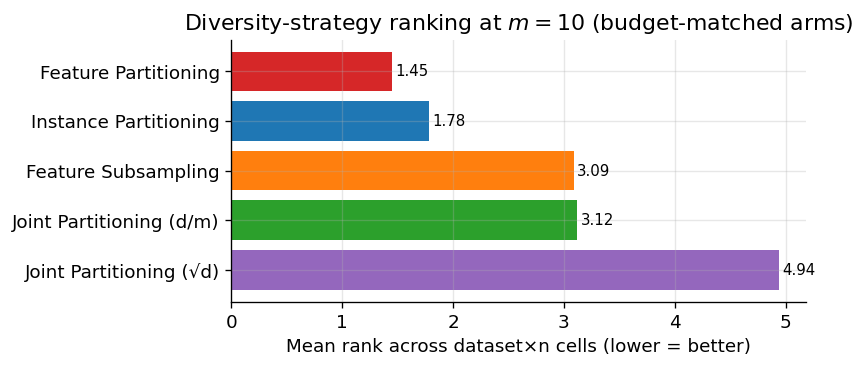

In [76]:
fig,ax=plt.subplots(figsize=(7,3.2))
r=ranking.sort_values("mean_rank")
ax.barh(r.index[::-1], r.mean_rank[::-1], color=[COLORS.get(x,"#555") for x in r.index[::-1]])
ax.set_xlabel("Mean rank across dataset×n cells (lower = better)")
ax.set_title("Diversity-strategy ranking at $m=10$ (budget-matched arms)")
for i,v in enumerate(r.mean_rank[::-1]): ax.text(v+0.03,i,f"{v:.2f}",va="center",fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/fig1_ranking.pdf",bbox_inches="tight"); plt.show()

### Fig 2 — Accuracy vs n per dataset at m=10 (regime split). Band = ±1 seed std.

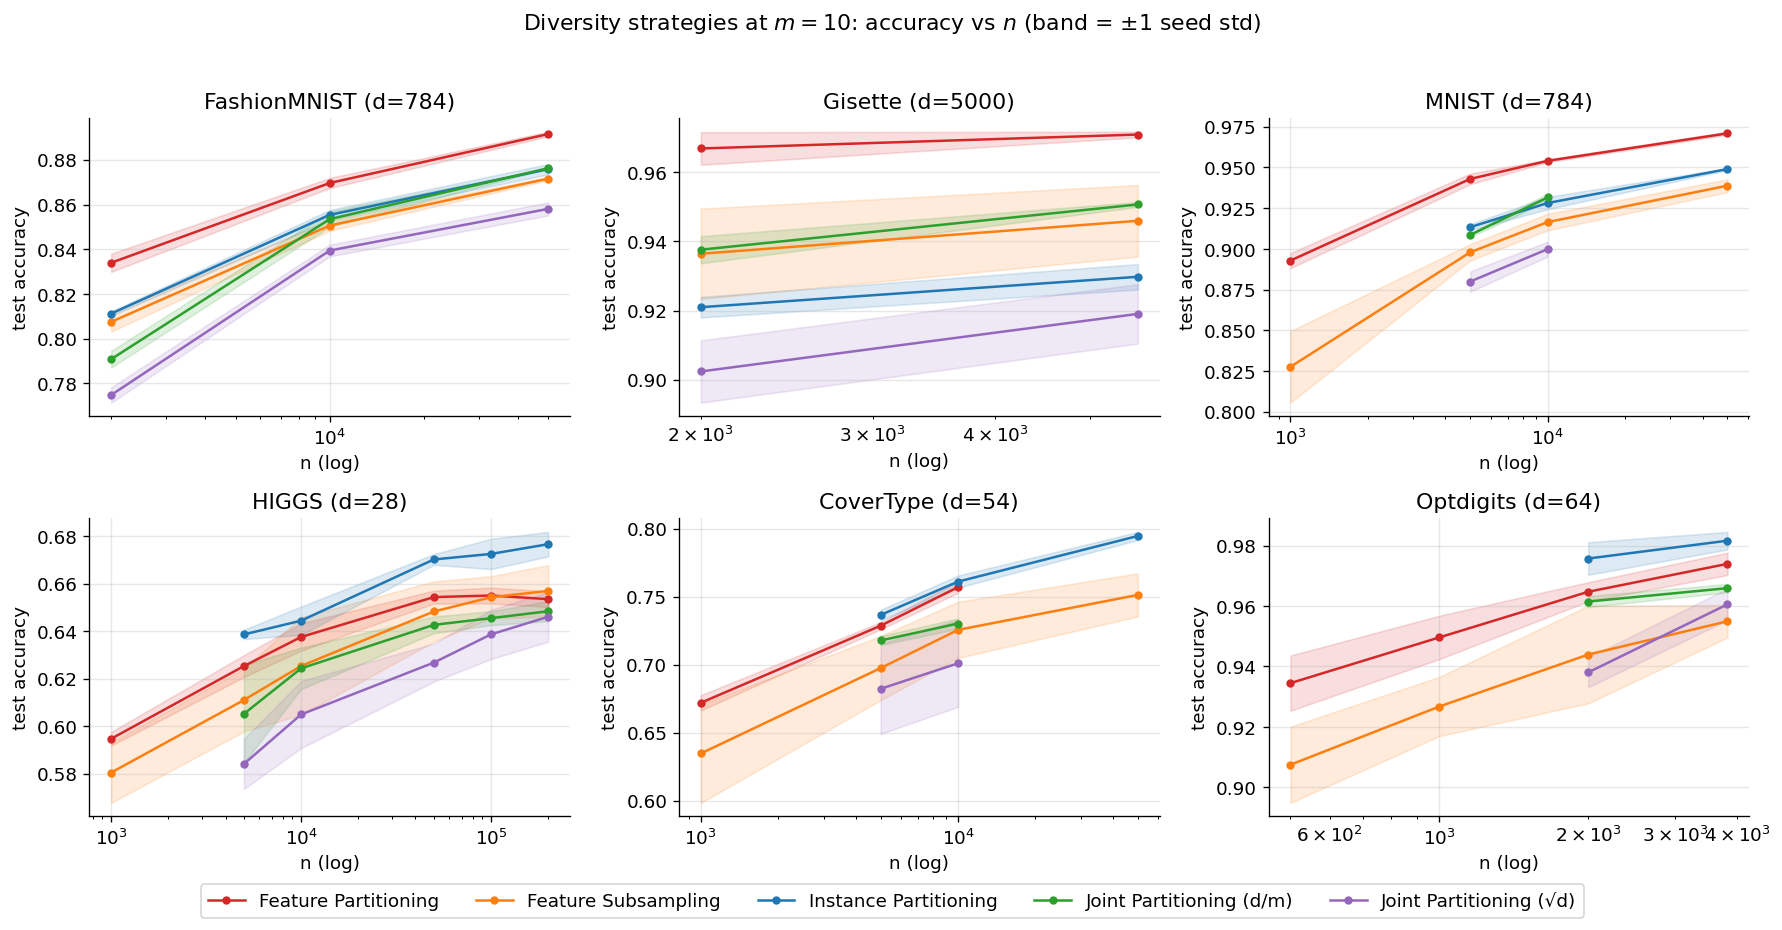

In [77]:
# datasets to show, in the requested order (row 1 = high-d, row 2 = regime contrast)
PLOT_ORDER = ["FashionMNIST","Gisette","MNIST","HIGGS","CoverType","Optdigits"]
plot_ds = [ds for ds in PLOT_ORDER if ds in bestL.dataset.unique()]

rk=bestL[(bestL.arm.isin(FEEDING_ARMS))&(bestL.m==10)]
ncol=3; nrow=int(np.ceil(len(plot_ds)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(5*ncol,3.6*nrow),squeeze=False)
for k,ds in enumerate(plot_ds):
    ax=axes[k//ncol][k%ncol]; s=rk[rk.dataset==ds]
    for lab,g in s.groupby("label"):
        g=g.sort_values("n_train")
        ax.plot(g.n_train,g.acc_mean,marker="o",ms=4,label=lab,color=COLORS.get(lab))
        ax.fill_between(g.n_train,g.acc_mean-g.acc_std,g.acc_mean+g.acc_std,alpha=0.15,color=COLORS.get(lab))
    ax.set_xscale("log"); ax.set_title(f"{ds} (d={int(df[df.dataset==ds].d.iloc[0])})")
    ax.set_xlabel("n (log)"); ax.set_ylabel("test accuracy")
for j in range(len(plot_ds),nrow*ncol): axes[j//ncol][j%ncol].axis("off")
h,l=axes[0][0].get_legend_handles_labels()
fig.legend(h,l,loc="lower center",ncol=5,bbox_to_anchor=(0.5,-0.04))
fig.suptitle("Diversity strategies at $m=10$: accuracy vs $n$ (band = ±1 seed std)",y=1.02)
plt.tight_layout(); plt.savefig(f"{FIG}/fig2_regime_split.pdf",bbox_inches="tight"); plt.show()

### Fig 3 — m>1 gain over the m=1 baseline vs n

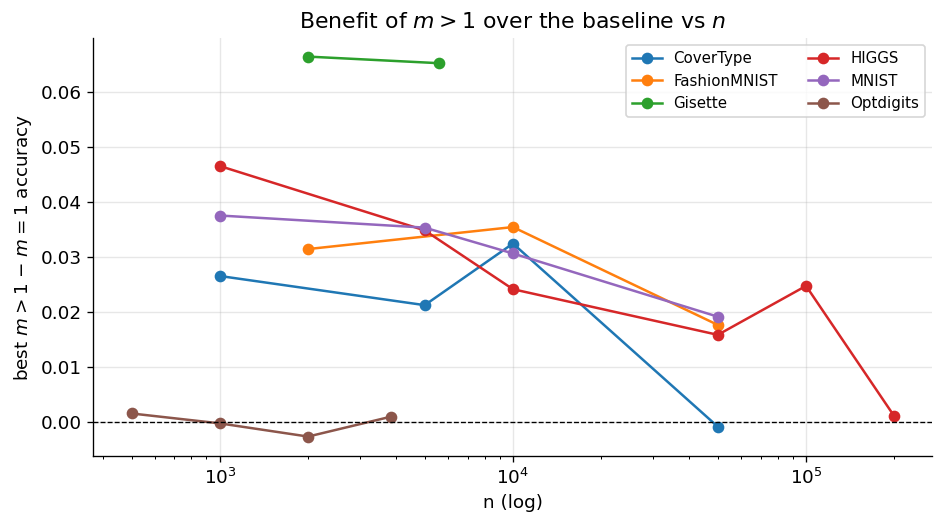

In [78]:
fig,ax=plt.subplots(figsize=(8,4.5))
for ds,g in gain.groupby("dataset"):
    g=g.sort_values("n"); ax.plot(g.n,g.gain,marker="o",label=ds)
ax.axhline(0,color="k",lw=0.8,ls="--"); ax.set_xscale("log")
ax.set_xlabel("n (log)"); ax.set_ylabel("best $m{>}1$ − $m{=}1$ accuracy")
ax.set_title("Benefit of $m>1$ over the baseline vs $n$"); ax.legend(fontsize=9,ncol=2)
plt.tight_layout(); plt.savefig(f"{FIG}/fig3_mgain.pdf",bbox_inches="tight"); plt.show()

### Fig 4 — The m=50 caveat (column-budget artifact, not a feeding verdict)

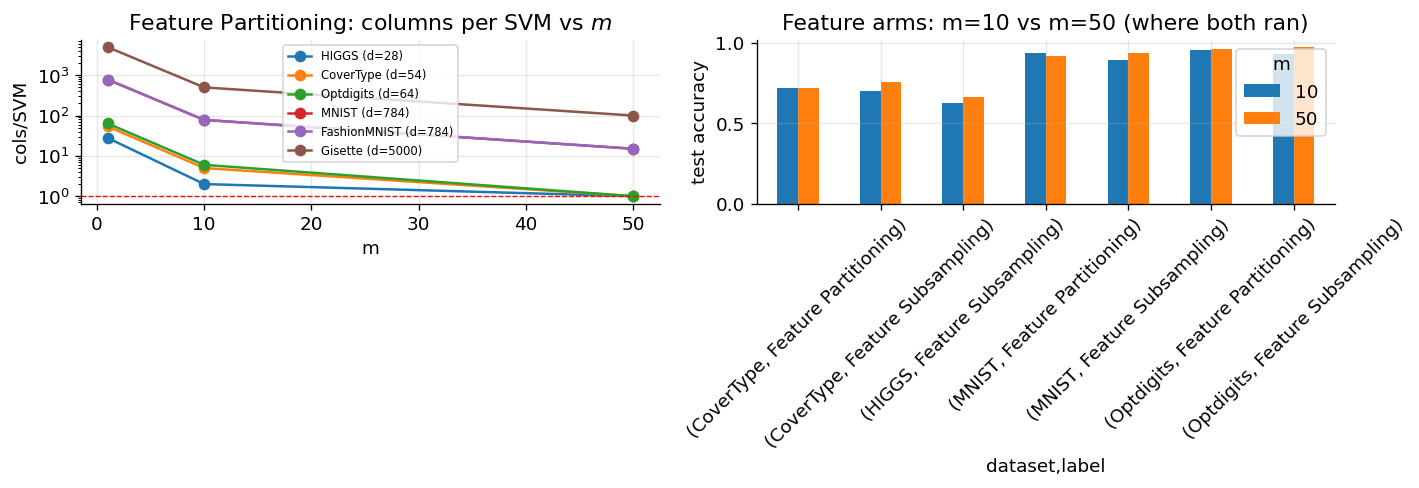

In [79]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.2))
dd=df[["dataset","d"]].drop_duplicates().set_index("dataset")["d"]; ms=[1,10,50]
for ds in DSORD:
    a1.plot(ms,[max(1,int(dd[ds])//m) for m in ms],marker="o",label=f"{ds} (d={int(dd[ds])})")
a1.axhline(1,color="r",ls="--",lw=0.8); a1.set_yscale("log")
a1.set_title("Feature Partitioning: columns per SVM vs $m$"); a1.set_xlabel("m"); a1.set_ylabel("cols/SVM"); a1.legend(fontsize=7)
sub=bestL[bestL.arm.isin(["B_in_dm","B_in_sqrt"])&bestL.m.isin([10,50])]
piv=sub.pivot_table(index=["dataset","label"],columns="m",values="acc_mean").dropna()
piv.plot.bar(ax=a2); a2.set_title("Feature arms: m=10 vs m=50 (where both ran)")
a2.set_ylabel("test accuracy"); a2.tick_params(axis="x",labelrotation=45)
plt.tight_layout(); plt.savefig(f"{FIG}/fig4_m50_caveat.pdf",bbox_inches="tight"); plt.show()

### Fig 5 — Depth effect L1→L2 by dataset

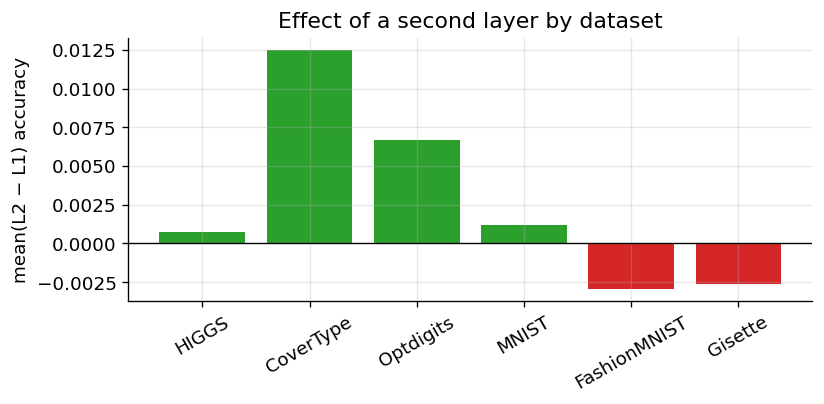

In [80]:
d2=cell[(cell.arm.isin(FEEDING_ARMS))&(cell.m>1)].pivot_table(index=["dataset","label","m","n_train"],columns="L",values="acc_mean")
if set([1,2]).issubset(d2.columns):
    d2=d2.dropna(subset=[1,2]); d2["dL"]=d2[2]-d2[1]
    dl=d2.groupby("dataset")["dL"].mean().reindex(DSORD)
    fig,ax=plt.subplots(figsize=(7,3.5))
    ax.bar(dl.index,dl.values,color=["#2ca02c" if v>0 else "#d62728" for v in dl.values])
    ax.axhline(0,color="k",lw=0.8); ax.set_ylabel("mean(L2 − L1) accuracy")
    ax.set_title("Effect of a second layer by dataset"); ax.tick_params(axis="x",labelrotation=30)
    plt.tight_layout(); plt.savefig(f"{FIG}/fig5_depth.pdf",bbox_inches="tight"); plt.show()

### Fig 6 — Decorrelation vs accuracy (feeding rows only, m>1)

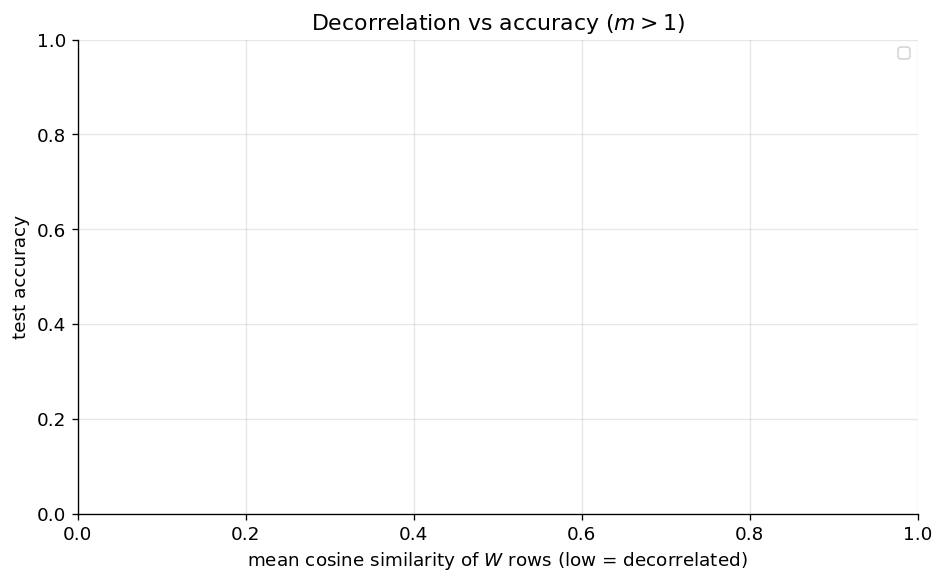

corr(cos, acc) by dataset:
figures: ['datasets_overview.pdf', 'fig1_ranking.pdf', 'fig2_regime_split.pdf', 'fig3_mgain.pdf', 'fig4_m50_caveat.pdf', 'fig5_depth.pdf', 'fig6_decorrelation.pdf', 'fig7_cd_diagram.pdf', 'provide_overfit_figures.py']


In [81]:
fdf=df[(df.source=="feeding")&(df.m>1)&df.cos.notna()]
fc=(fdf.groupby(["dataset","arm","m","L","n_train"]).agg(acc=("acc","mean"),cos=("cos","mean")).reset_index())
fig,ax=plt.subplots(figsize=(8,5))
for ds,g in fc.groupby("dataset"): ax.scatter(g.cos,g.acc,alpha=0.6,label=ds)
ax.set_xlabel("mean cosine similarity of $W$ rows (low = decorrelated)")
ax.set_ylabel("test accuracy"); ax.set_title("Decorrelation vs accuracy ($m>1$)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/fig6_decorrelation.pdf",bbox_inches="tight"); plt.show()
print("corr(cos, acc) by dataset:")
for ds,g in fc.groupby("dataset"):
    if len(g)>3: print(f"  {ds:10s} r={g.cos.corr(g.acc):+.3f} (n={len(g)})")
print("figures:", sorted(os.listdir("figures")))

## 13. Statistical significance of the ranking (Friedman + Nemenyi)

A bare mean-rank table does not establish that the strategies differ beyond chance. We apply the
standard protocol for comparing multiple methods over multiple datasets (Demšar, 2006): a
**Friedman test** for an overall difference in ranks, followed by a **Nemenyi post-hoc** test that
yields a single *critical difference* (CD); two strategies are significantly different at
$\alpha=0.05$ iff their average ranks differ by more than the CD. Each (dataset, $n$) cell at
$m=10$ is one block; the five budget-matched feeding strategies are the treatments.

In [82]:
from scipy.stats import friedmanchisquare, rankdata

# blocks = (dataset, n) cells at m=10; treatments = the 5 budget-matched feeding arms
RANK_SRC = bestL[(bestL.arm.isin(FEEDING_ARMS)) & (bestL.m==10)].copy()
M = RANK_SRC.pivot_table(index=["dataset","n_train"], columns="label", values="acc_mean")
M = M.dropna(axis=0)                      # complete blocks only (every strategy ran)
strategies = list(M.columns); k = len(strategies); Nb = len(M)
print(f"Friedman/Nemenyi over N={Nb} blocks (dataset x n) and k={k} strategies\n")

stat, p = friedmanchisquare(*[M[c].values for c in strategies])
print(f"Friedman chi^2 = {stat:.3f},  p = {p:.3e}")
print("=> strategies differ in rank beyond chance" if p<0.05 else "=> no significant overall difference")

# average ranks (1 = best within each block)
R = M.apply(lambda r: rankdata(-r.values), axis=1, result_type="expand"); R.columns = strategies
avg_rank = R.mean().sort_values()
print("\nAverage ranks (1 = best):"); print(avg_rank.round(3).to_string())

# Nemenyi critical difference: CD = q_alpha * sqrt(k(k+1)/(6N))
q05 = {2:1.960,3:2.343,4:2.569,5:2.728,6:2.850,7:2.949,8:3.031,9:3.102,10:3.164}
CD = q05[k]*np.sqrt(k*(k+1)/(6*Nb))
print(f"\nNemenyi CD (alpha=0.05) = {CD:.3f}\n")
print("Pairwise average-rank differences ( * = significant at 0.05 ):")
sig_pairs=[]
for i in range(k):
    for j in range(i+1,k):
        a,b = avg_rank.index[i], avg_rank.index[j]
        d = abs(avg_rank[a]-avg_rank[b]); s = d>CD
        if s: sig_pairs.append((a,b,d))
        print(f"  {a:20s} vs {b:20s}: {d:.3f} {'*' if s else ''}")

Friedman/Nemenyi over N=16 blocks (dataset x n) and k=5 strategies

Friedman chi^2 = 46.850,  p = 1.639e-09
=> strategies differ in rank beyond chance

Average ranks (1 = best):
Feature Partitioning        1.625
Instance Partitioning       1.812
Joint Partitioning (d/m)    3.125
Feature Subsampling         3.500
Joint Partitioning (√d)     4.938

Nemenyi CD (alpha=0.05) = 1.525

Pairwise average-rank differences ( * = significant at 0.05 ):
  Feature Partitioning vs Instance Partitioning: 0.188 
  Feature Partitioning vs Joint Partitioning (d/m): 1.500 
  Feature Partitioning vs Feature Subsampling : 1.875 *
  Feature Partitioning vs Joint Partitioning (√d): 3.312 *
  Instance Partitioning vs Joint Partitioning (d/m): 1.312 
  Instance Partitioning vs Feature Subsampling : 1.688 *
  Instance Partitioning vs Joint Partitioning (√d): 3.125 *
  Joint Partitioning (d/m) vs Feature Subsampling : 0.375 
  Joint Partitioning (d/m) vs Joint Partitioning (√d): 1.812 *
  Feature Subsampling  vs 

### Fig 7 — Critical-difference diagram

The diagram places each strategy on the rank axis (best = left). A bar joins strategies whose ranks
differ by less than the CD, i.e. those that are **not** statistically distinguishable. This is the
figure to put in the paper: it shows at a glance that the two leading strategies are indistinguishable
from each other yet significantly better than the joint-partition strategies.

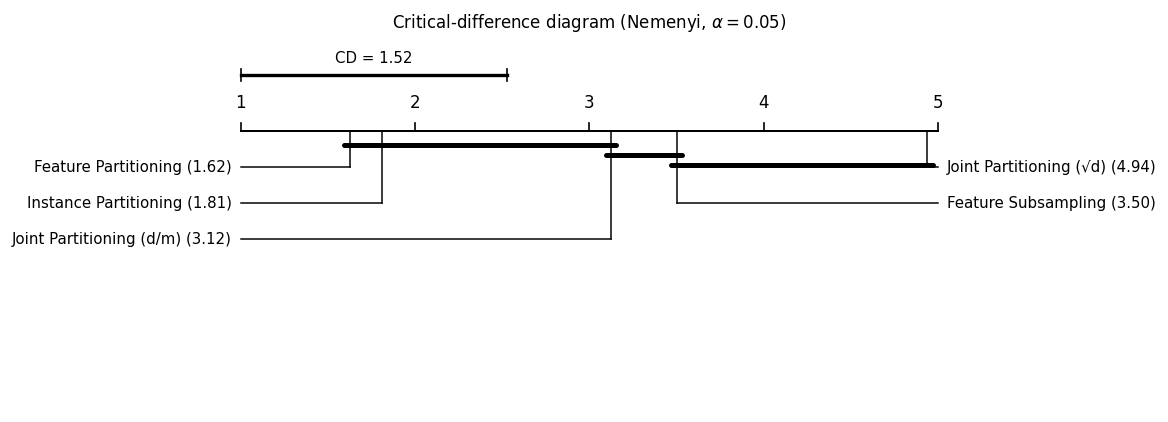

non-significant cliques (rank ranges): [(np.float64(1.62), np.float64(3.12)), (np.float64(3.12), np.float64(3.5)), (np.float64(3.5), np.float64(4.94))]


In [83]:
def cd_diagram(avg_rank, CD, fname, title=None):
    """Demsar critical-difference diagram with non-significance clique bars."""
    items = sorted(avg_rank.items(), key=lambda kv: kv[1])
    names = [n for n,_ in items]; ranks = np.array([r for _,r in items])
    k = len(names); lo=1; hi=int(np.ceil(ranks.max()))
    cliques=[]
    for i in range(k):
        j=i
        while j+1<k and (ranks[j+1]-ranks[i])<=CD: j+=1
        if j>i: cliques.append((ranks[i],ranks[j]))
    cliques=[c for c in cliques if not any(c!=o and o[0]<=c[0] and c[1]<=o[1] for o in cliques)]
    half=int(np.ceil(k/2)); ay=1.2; gap=0.18
    fig,ax=plt.subplots(figsize=(9,0.5*k+1.6)); ax.set_xlim(lo-0.4,hi+0.4); ax.set_ylim(-0.2,1.7); ax.axis("off")
    ax.plot([lo,hi],[ay,ay],color="k",lw=1.2)
    for x in range(lo,hi+1):
        ax.plot([x,x],[ay,ay+0.04],color="k",lw=1); ax.text(x,ay+0.10,str(x),ha="center",va="bottom",fontsize=10)
    for idx,(nm,r) in enumerate(zip(names,ranks)):
        left = idx<half; row = idx if left else (k-1-idx); y=ay-0.18-row*gap; edge = lo if left else hi
        ax.plot([r,r],[ay,y],color="k",lw=0.9); ax.plot([r,edge],[y,y],color="k",lw=0.9)
        ax.text(edge+(-0.05 if left else 0.05),y,f"{nm} ({r:.2f})",ha="right" if left else "left",va="center",fontsize=9)
    by=ay-0.07
    for (a,b) in cliques:
        ax.plot([a-0.03,b+0.03],[by,by],color="k",lw=3,solid_capstyle="round"); by-=0.05
    ax.plot([lo,lo+CD],[ay+0.28,ay+0.28],color="k",lw=2)
    ax.plot([lo,lo],[ay+0.25,ay+0.31],color="k",lw=1); ax.plot([lo+CD,lo+CD],[ay+0.25,ay+0.31],color="k",lw=1)
    ax.text(lo+CD/2,ay+0.33,f"CD = {CD:.2f}",ha="center",va="bottom",fontsize=9)
    if title: ax.text((lo+hi)/2,ay+0.52,title,ha="center",fontsize=10)
    plt.savefig(fname,bbox_inches="tight",dpi=200); plt.show()
    return cliques

cl = cd_diagram(avg_rank.to_dict(), CD, f"{FIG}/fig7_cd_diagram.pdf",
                title="Critical-difference diagram (Nemenyi, $\\alpha=0.05$)")
print("non-significant cliques (rank ranges):", [(round(a,2),round(b,2)) for a,b in cl])

## 14. Decorrelation vs accuracy — per-dataset correlation with significance

The discussion claims that decorrelating the \glspl{svm} (lower mean cosine similarity of $W$ rows)
does not, by itself, buy accuracy. We quantify this with the Pearson correlation between mean cosine
similarity and test accuracy across the $m>1$ configurations, per dataset, with a two-sided $p$-value.
A correlation that is near zero or negative supports the *stacking* interpretation over pure ensemble
averaging.

In [84]:
from scipy.stats import pearsonr

# The main results CSV stores no cosine column (its 12th field is split_id, not mean_cos_sim),
# so cosine for ALL datasets comes from feeding_cos.csv. That file is produced by:
#   - parse_feeding_cos.py        (original 5 logs: MNIST, Digits8x8, Optdigits, Satimage, CoverType)
#   - parse_feeding_cos_highd.py  (appends the new high-d logs: FashionMNIST, Gisette)
cosdf = pd.read_csv("feeding_cos.csv")
cosdf = cosdf[cosdf.dataset.isin(KEEP_DATASETS)].copy()   # same six-dataset panel
cosdf = cosdf[(cosdf.m > 1) & (cosdf.cos_sim < 0.999)].copy()
print(f"usable cosine rows (m>1): {len(cosdf)}")
print("points per dataset:", cosdf.groupby("dataset").size().to_dict())

# --- per-dataset correlation: the VALID statistic ---
COLS = ["dataset","n_points","pearson_r","p_value","sig"]
drows = []
for ds, g in cosdf.groupby("dataset"):
    if len(g) >= 4 and g["cos_sim"].nunique() >= 3 and g["acc"].nunique() >= 3:
        r, pv = pearsonr(g["cos_sim"], g["acc"])
        drows.append(dict(dataset=ds, n_points=int(len(g)),
                          pearson_r=round(float(r),3), p_value=round(float(pv),3),
                          sig=("yes" if pv<0.05 else "no")))
decorr = pd.DataFrame(drows, columns=COLS).sort_values("pearson_r")
print("\nPer-dataset correlation between W-row cosine similarity and accuracy (m>1):")
display(decorr)

# --- pooled value: cautionary only (Simpson's paradox), NOT the headline ---
if len(cosdf) > 3:
    pooled_r, pooled_p = pearsonr(cosdf["cos_sim"], cosdf["acc"])
    print(f"\n[caution] Pooled r={pooled_r:+.3f} (p={pooled_p:.3f}) is CONFOUNDED across datasets;"
          f"\nthe per-dataset rows above are the valid statistic.")

n_sig = (decorr["sig"]=="yes").sum()
print(f"\nResult: {n_sig} of {len(decorr)} datasets show a significant cos-accuracy correlation.")
print("Weak/non-significant per-dataset correlations => decorrelation does not by itself")
print("improve accuracy, consistent with stacking rather than pure ensemble averaging.")


usable cosine rows (m>1): 194
points per dataset: {'CoverType': 48, 'FashionMNIST': 30, 'Gisette': 20, 'MNIST': 52, 'Optdigits': 44}

Per-dataset correlation between W-row cosine similarity and accuracy (m>1):


,dataset,n_points,pearson_r,p_value,sig
0,CoverType,48,-0.100,0.499,no
1,FashionMNIST,30,0.003,0.987,no
4,Optdigits,44,0.126,0.415,no
3,MNIST,52,0.149,0.293,no
2,Gisette,20,0.879,0.000,yes



[caution] Pooled r=+0.281 (p=0.000) is CONFOUNDED across datasets;
the per-dataset rows above are the valid statistic.

Result: 1 of 5 datasets show a significant cos-accuracy correlation.
Weak/non-significant per-dataset correlations => decorrelation does not by itself
improve accuracy, consistent with stacking rather than pure ensemble averaging.


### LaTeX export for the significance results

Writes `tables/feeding_friedman.tex` (average ranks + CD) and `tables/feeding_decorrelation.tex`
(per-dataset correlations) so they can be `\input` directly into the thesis.

In [85]:
import os
os.makedirs("tables", exist_ok=True)
def esc(s): return str(s).replace("_", r"\_")

# ---- Friedman / Nemenyi average-rank table ----
ar = avg_rank.reset_index(); ar.columns = ["Strategy","Avg. rank"]
rows_tex = " \\\\\n".join(f"{esc(r['Strategy'])} & {r['Avg. rank']:.2f}" for _,r in ar.iterrows())
cap_fried = ("Average ranks of the feeding strategies at $m=10$ over the "
             + str(Nb) + " (dataset, $n$) blocks. A Friedman test rejects rank equality "
             "($\\chi^2=" + f"{stat:.1f}" + "$, $p<0.001$); the Nemenyi critical difference is "
             "$\\mathrm{CD}=" + f"{CD:.2f}" + "$, so strategies whose ranks differ by more than "
             + f"{CD:.2f}" + " are significantly different at $\\alpha=0.05$.")
fried = ("\\begin{table}[ht]\n\\centering\\small\n\\begin{tabular}{lc}\n\\toprule\n"
         "Feeding strategy & Average rank \\\\\n\\midrule\n"
         + rows_tex + " \\\\\n\\bottomrule\n\\end{tabular}\n"
         "\\caption{" + cap_fried + "}\n\\label{tab:feeding_friedman}\n\\end{table}\n")
open("tables/feeding_friedman.tex","w").write(fried)

# ---- Decorrelation table ----
db = " \\\\\n".join(
    f"{esc(r['dataset'])} & {int(r['n_points'])} & ${r['pearson_r']:+.3f}$ & {r['p_value']:.3f}"
    for _,r in decorr.iterrows())
cap_deco = ("Pearson correlation between the mean cosine similarity of the rows of $\\mathbf{W}$ "
            "and test accuracy across the $m>1$ configurations, per dataset. Pooled: $r="
            + f"{pooled_r:+.3f}" + "$ ($n=" + str(len(fc)) + "$). Correlations near zero or negative "
            "indicate that decorrelation does not by itself improve accuracy.")
deco = ("\\begin{table}[ht]\n\\centering\\small\n\\begin{tabular}{lccc}\n\\toprule\n"
        "Dataset & \\# configs & Pearson $r$ & $p$ \\\\\n\\midrule\n"
        + db + " \\\\\n\\bottomrule\n\\end{tabular}\n"
        "\\caption{" + cap_deco + "}\n\\label{tab:feeding_decorrelation}\n\\end{table}\n")
open("tables/feeding_decorrelation.tex","w").write(deco)
print("wrote tables/feeding_friedman.tex and tables/feeding_decorrelation.tex")


wrote tables/feeding_friedman.tex and tables/feeding_decorrelation.tex
